# Experiment A1: parse JSF
Lets try to read one of the JSF files. Interpret them using this spec:
  https://www.edgetech.com/wp-content/uploads/2019/07/0023492_Rev_E.pdf

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
import sys

#%pip install opencv-python


import glob
import cv2

from tqdm import tqdm

from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Message definition

In [2]:
import struct

In [18]:
header_format = [
    {"struct_type": "H", "dtype": "UINT16", "field_name": "synch_marker"      , "description": "Synch Marker, always 0x1601"},
    {"struct_type": "B", "dtype": "UINT8" , "field_name": "protocol_version"  , "description": "Protocol version"},
    {"struct_type": "B", "dtype": "UINT8" , "field_name": "session_identifier", "description": "Session identifier"},
    {"struct_type": "H", "dtype": "UINT16", "field_name": "message_type"      , "description": "Message type"},
    {"struct_type": "B", "dtype": "UINT8" , "field_name": "command_type"      , "description": "Command type"},
    {"struct_type": "B", "dtype": "UINT8" , "field_name": "subsystem_number"  , "description": "Subsystem number"},
    {"struct_type": "B", "dtype": "UINT8" , "field_name": "channel"           , "description": "Channel 0=port, 1=starboard"},
    {"struct_type": "B", "dtype": "UINT8" , "field_name": "sequence_number"   , "description": "Sequence number"},
    {"struct_type": "H", "dtype": "UINT16", "field_name": "reserved"          , "description": "Reserved"},
    {"struct_type": "i", "dtype": "INT32" , "field_name": "payload_length"    , "description": "Payload message length"}
]

struct_fmt = "".join([h['struct_type'] for h in header_format])
struct_len = struct.calcsize(struct_fmt)
struct_unpack = struct.Struct(struct_fmt).unpack_from


HBBHBBBBHi
<built-in method unpack_from of Struct object at 0x000001E1DCE5E270>


## Read all message from a single file

In [21]:
def decode_message(unpacked_struct):
    message = {}
    for i in range(len(unpacked_struct)):
        field_name = header_format[i]['field_name']
        field_value = unpacked_struct[i]
        message[field_name] = field_value
        
    return message


messages = []
#counter = 0
with tqdm() as p, open("4125_sample_data.jsf", 'rb') as fp:
    while True:
        data = fp.read(struct_len)
        if not data:
            break
            
        unpacked_struct = struct_unpack(data)
        message = decode_message(unpacked_struct)
        message['payload'] = fp.read(message['payload_length'])
        #print(message)
        #counter += 1
        #if counter == 3: break
        messages.append(message)
        p.update()
        

3007it [00:00, 130733.70it/s]


## Inspect messages
According to this site the 4125 Sonar should be able to send the following message types:
https://ge0mlib.com/download.htm
```
Type	Description
40      Acoustic Return Data
80      Sonar Data Message
181     Navigation offsets
182     System information
1065	?
2002	NMEA string
2020	Pitch Roll Data
2040	?
2060	Pressure Sensor Reading
```

In [92]:
df = pd.DataFrame(messages)
#print(messages[0:2])
print(len(messages))
print(np.frombuffer(df[df.message_type == 2002].iloc[56].payload[8:9], dtype=np.int8))
print(df[df.message_type == 2002].iloc[56])
print(df)

3007
[3]
synch_marker                                                       5633
protocol_version                                                      9
session_identifier                                                    0
message_type                                                       2002
command_type                                                          2
subsystem_number                                                    100
channel                                                               0
sequence_number                                                       0
reserved                                                              0
payload_length                                                       31
payload               b'V\x864G\x90\x01\x00\x00\x03\x00\x00\x00$GPBO...
Name: 609, dtype: object
      synch_marker  protocol_version  session_identifier  message_type  \
0             5633                 9                   0           182   
1             5633        

In [6]:
print("Message_type counts")
df.message_type.value_counts().sort_index()

Message_type counts


80      2723
181        1
182        1
2002     282
Name: message_type, dtype: int64

In [7]:
print("Sonar Data Message (type 80) message count per channel")
df[df.message_type == 80].channel.value_counts()

Sonar Data Message (type 80) message count per channel


1    1362
0    1361
Name: channel, dtype: int64

In [39]:
print("Statistics per message type")


combi = df[['message_type', 'payload_length']].groupby('message_type').sum()

combi['count'] = df.message_type.value_counts().sort_index()
combi['average_length'] = df[['message_type', 'payload_length']].groupby('message_type').mean().round()

print(combi)

combi['count'] = df.message_type.value_counts().sort_index()
combi['average_length'] = df[['message_type', 'payload_length']].groupby('message_type').mean().round()
combi['payload_sample'] = pd.Series(
    data=[
        df[df.message_type == message_type].payload.values[0].decode('latin-1', errors='replace')
        for message_type in sorted(df.message_type.unique())],
    index=sorted(df.message_type.unique())
)

combi

Statistics per message type
              payload_length  count  average_length
message_type                                       
80                   9732002   2723          3574.0
181                       64      1            64.0
182                     1648      1          1648.0
2002                   16169    282            57.0


,payload_length,count,average_length,payload_sample
message_type,,,,
80,9732002,2723,3574.0,L4G    ¥                  o        Î\n  ...
181,64,1,64.0,                                              ...
182,1648,1,1648.0,                                            ...
2002,16169,282,57.0,"N4G      $GPRMC,160952,A,4136.5249,N,07053...."


## Visualize *Sonar Trace Data* from  Data Message (type 80) payload
From the IRS:

2.2.1 Message Type 80: Sonar Data Message (jsfdefs.h)
The Sonar Data Message consists of a single channel ping of data (receiver sounding period) for a single
channel (e.g., port side of low frequency side scan subsystem). Most side scan subsystems have two data
channels: port and starboard. Most sub-bottom subsystems have a single data channel. Which fields have
data present depends on the system used and data acquisition procedures. In addition, this message may
contain data from multiple non-acoustic sensors. Non-acoustic data contained in this message normally
is not time interpolated.
EdgeTech strongly recommends that if high positional or situational accuracy is required, the individual
sensor messages should be processed instead (see sub-section 2.4 AUXILIARY MESSAGES). Otherwise, this
may be the only message that needs to be interpreted in a JSF file if the level of accuracy is sufficient. The
Validity Flag field (byte 30-31) indicates which auxiliary fields are populated. By convention, if a value is
not present, the field is set to 0.
A Sonar Data Message consists of a 240-byte header followed by the actual acoustic sample data. This
240-byte header is described in the table below.

(SKIP)

**Sonar trace data** follows the 240-byte header and consists of 16-bit integer values. The number of integers
to be read is found by multiplying the number of samples in the trace (bytes 114-115) by the number of
integers per sample for the data type used (1 or 2). Furthermore, doubling this yields the byte size of the
data section. This should exactly match the preceding Message Header byte count (bytes 12 –15) less the
header size of 240.

In [46]:
# Simple RAW decode of the Sonar Trace Data from a single sensor side (0=port, 1=starboard)
SENSOR_SIDE = 1

def decode_sonar_trace_data(m):
    sonar_message_header_length = 240
    timestamp = np.frombuffer(m['payload'][:4], dtype=np.int32)[0]
    validities = np.frombuffer(m['payload'][30:32], dtype=np.uint16)[0]
    speed_valid = (validities & 1 << 2) > 0
    speed = np.frombuffer(m['payload'][194:196], dtype=np.int16)[0] if speed_valid else None
    
    if speed is not None:
        # Convert 1/10 knots to km/h
        speed = (speed * 0.051).round(2)
    
    data = m['payload'][sonar_message_header_length:]
    data = np.frombuffer(data, dtype=np.int16)
    return {'timestamp': timestamp,
            'speed': speed,
            'sonar_trace_data': data}


payloads = []
for m in tqdm(messages):
    if m['message_type'] == 80 and m['channel'] == SENSOR_SIDE:
        payloads.append(decode_sonar_trace_data(m))
       
len(payloads)    

100%|██████████████████████████████████████████████████████████████████████████| 3007/3007 [00:00<00:00, 125303.24it/s]


1362

In [48]:
payloads_df = pd.DataFrame(payloads, columns=['timestamp', 'speed'])
payloads_df['date'] = pd.to_datetime(payloads_df.timestamp, unit='s')
#print(payloads)

In [11]:
print(f"Recording start    : {payloads_df.date.min()}")
print(f"Recording end      : {payloads_df.date.max()}")
print(f"Recording duration : {payloads_df.date.max()-payloads_df.date.min()}")

mean_speed = payloads_df.speed.mean()
total_seconds = (payloads_df.date.max()-payloads_df.date.min()).total_seconds()
travel_distance = mean_speed * total_seconds
print(f"Travel distance    : ~{travel_distance:1.2f} meters")

Recording start    : 2007-11-09 16:09:48
Recording end      : 2007-11-09 16:10:36
Recording duration : 0 days 00:00:48
Travel distance    : ~90.18 meters


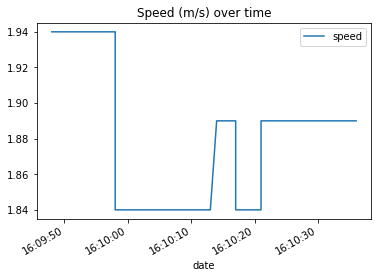

In [12]:
_ = payloads_df.plot(x='date', y='speed', title='Speed (m/s) over time')

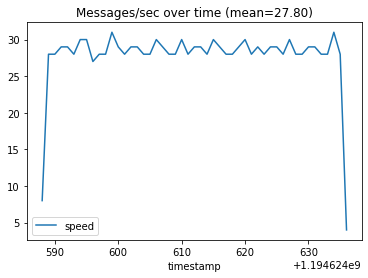

In [13]:
messages_per_sec_over_time = payloads_df[['timestamp', 'speed']].groupby('timestamp').count()
_ = messages_per_sec_over_time.plot(
    title=f'Messages/sec over time (mean={messages_per_sec_over_time.mean().values[0]:0.2f})')

In [53]:
print(payloads[4]['sonar_trace_data'])
# Concat all trace data
trace_data_concat = np.stack([i['sonar_trace_data'] for i in payloads])

print(f"Data shape : {trace_data_concat.shape}")
print(f"Vmin       : {trace_data_concat.min()}")
print(f"Vmax       : {trace_data_concat.max()}")

[ 50   0  32 ...  44  72 400]
Data shape : (1362, 1667)
Vmin       : 0
Vmax       : 3968


Small sample (~90 meters)


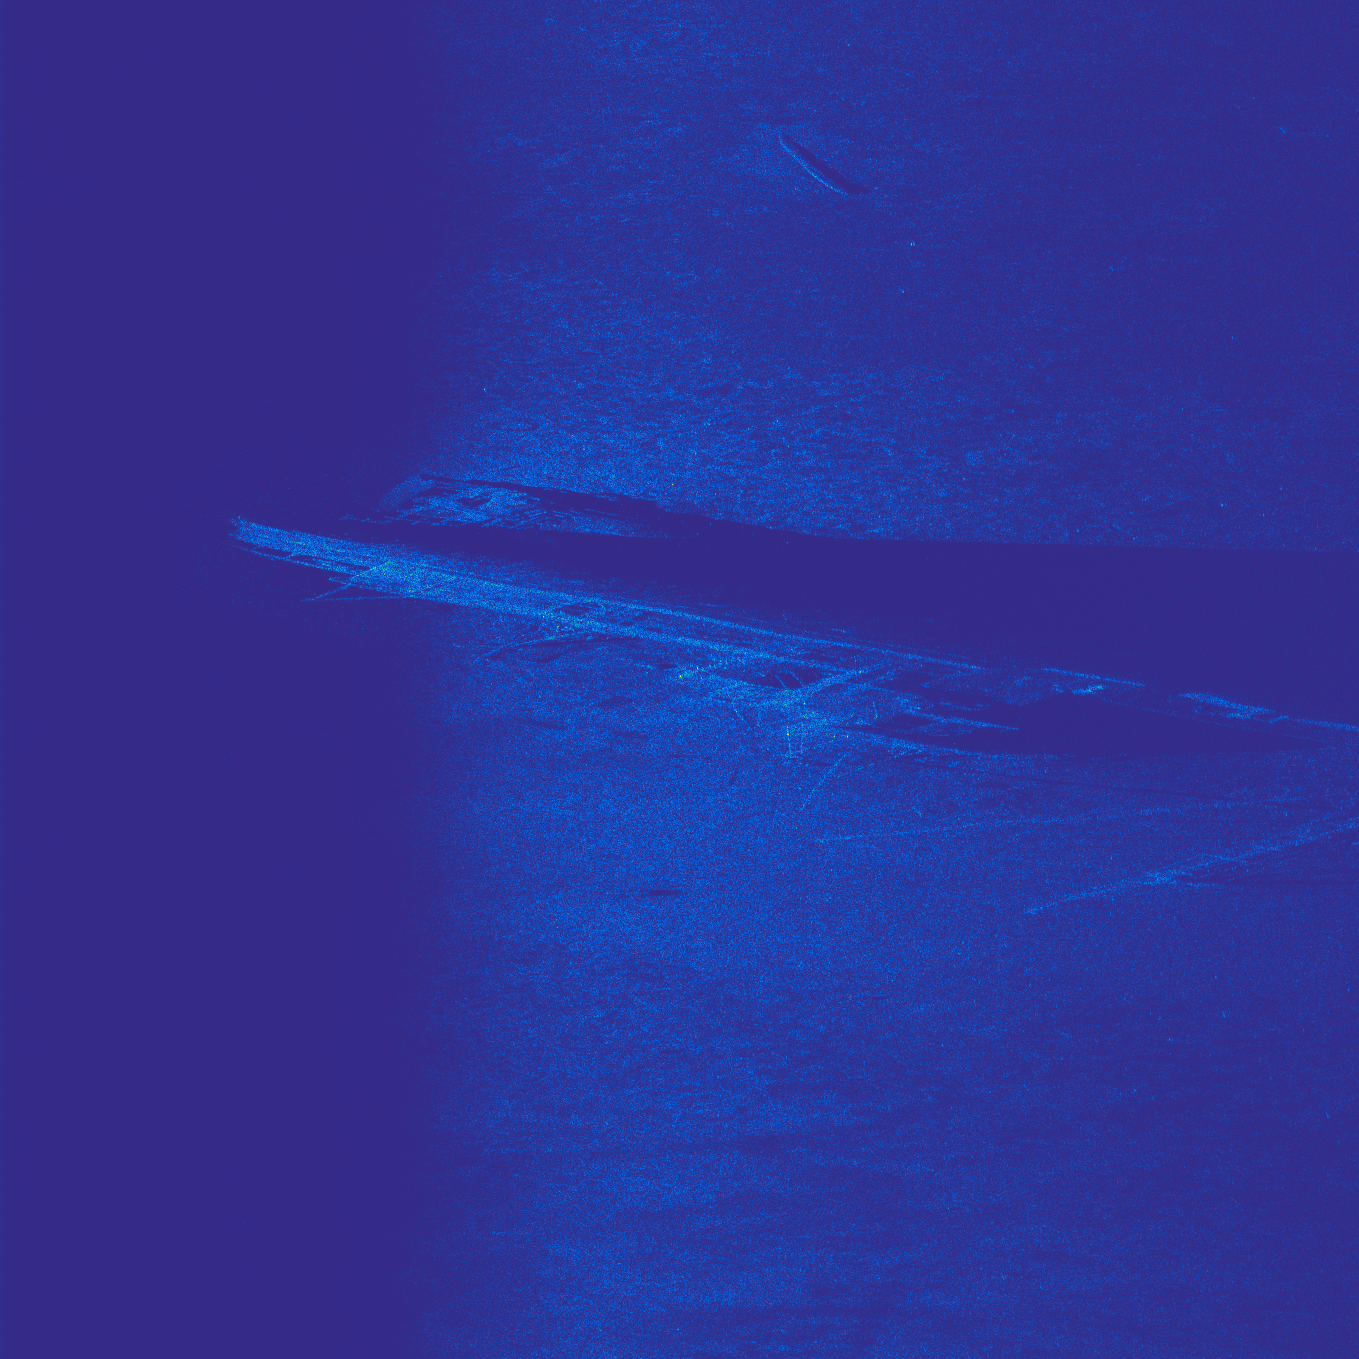

In [94]:
N_METERS = 90
sample_count = int(trace_data_concat.shape[0] * N_METERS / travel_distance)

pic = trace_data_concat[:sample_count, :sample_count]

print(f"Small sample (~{N_METERS} meters)")
pic = cv2.normalize(pic, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
pic = cv2.applyColorMap(pic, cv2.COLORMAP_PARULA)
pic = cv2.cvtColor(pic, cv2.COLOR_BGR2RGB)
cv2.imwrite("sonar3.jpg",pic)
display(Image.fromarray(pic))

Overview


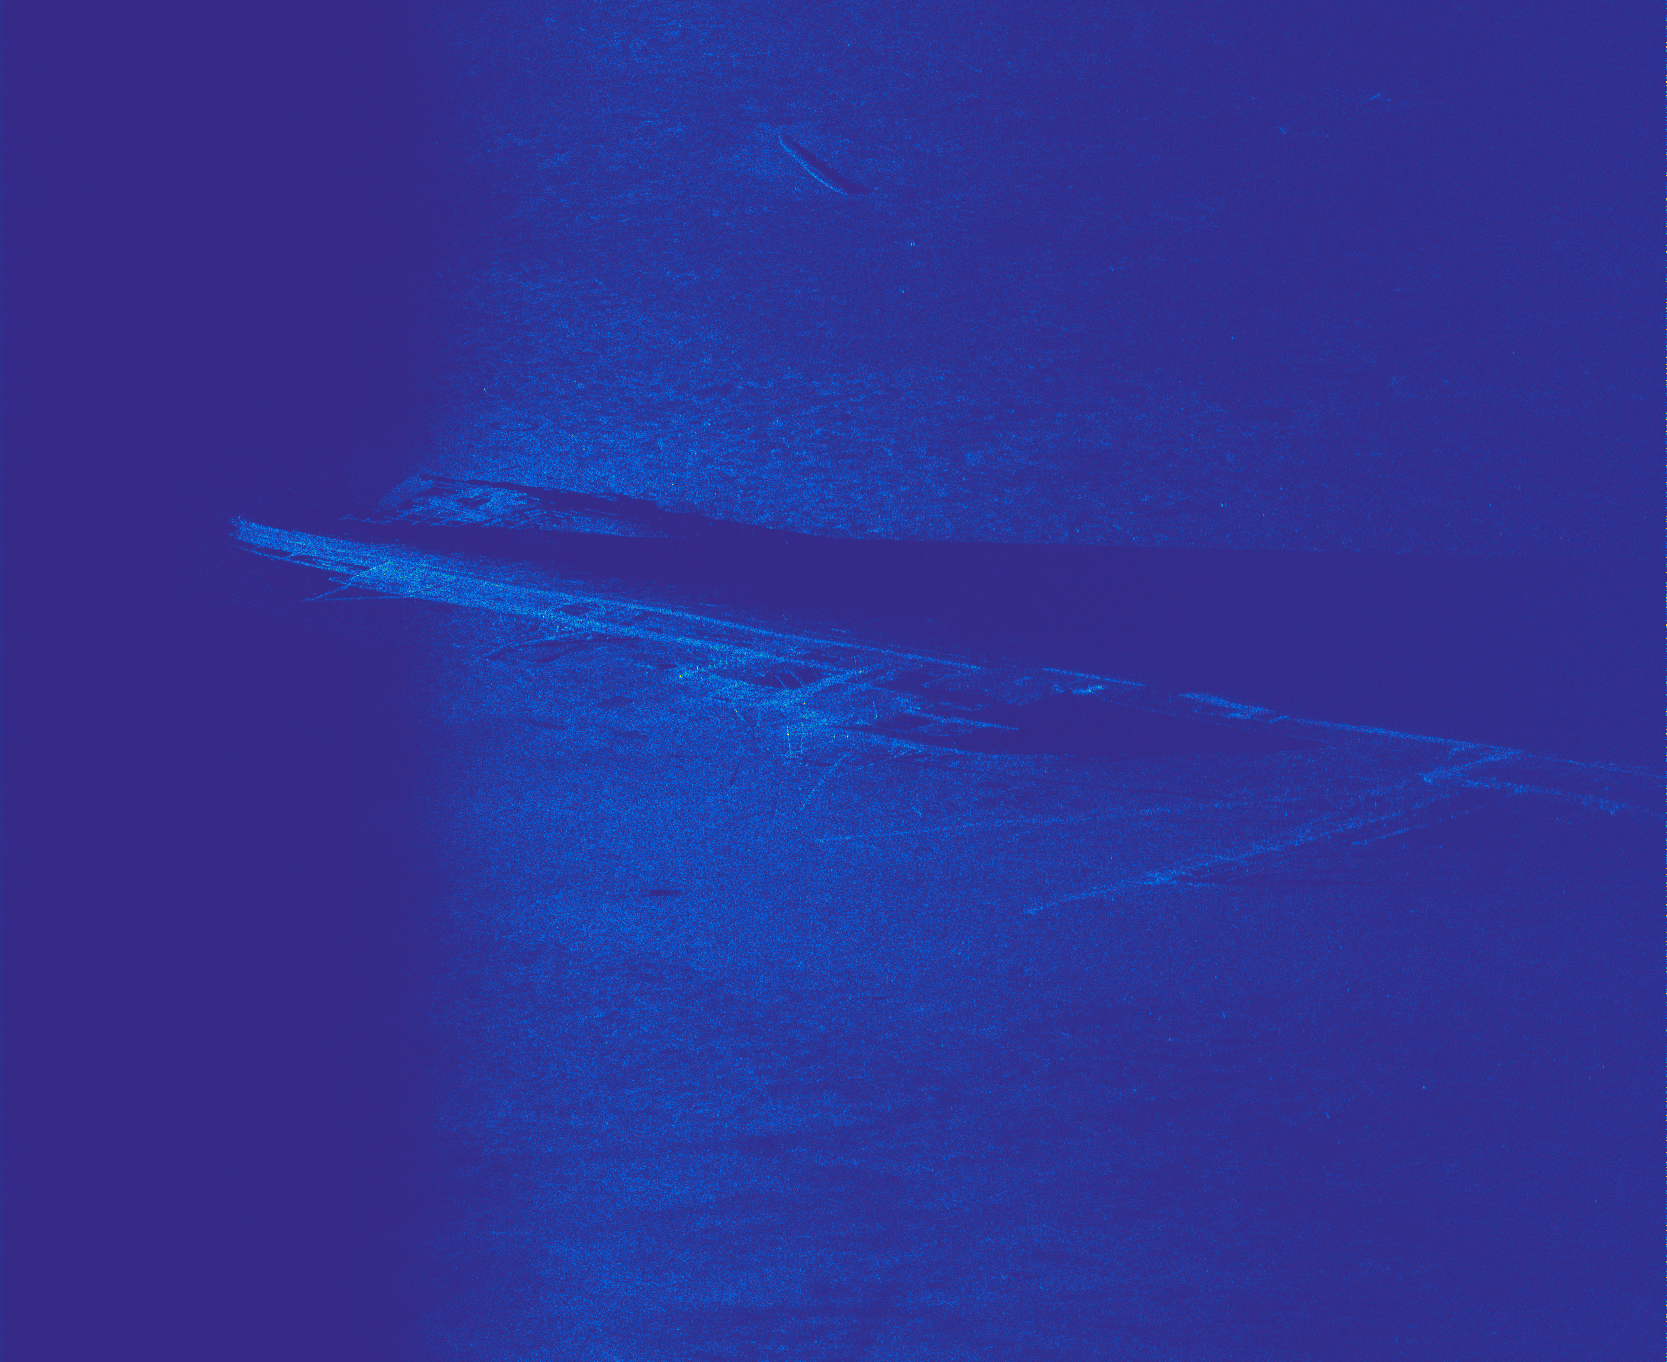

In [16]:
print("Overview")
pic = cv2.normalize(trace_data_concat, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
#pic = mlcvtools.image_resize_aspect(pic, height=1000)
#pic.resize((500,1000))
pic = cv2.applyColorMap(pic, cv2.COLORMAP_PARULA)
pic = cv2.cvtColor(pic, cv2.COLOR_BGR2RGB)
display(Image.fromarray(pic))

In [17]:
cv2.imwrite("sonar4.jpg",pic)

True